# Méthode supervisée avec PyTorch sur GTSRB

## Objectif

Dans cette partie, on met en place une première approche supervisée pour classifier les panneaux de signalisation du dataset **GTSRB**.

Pour accélérer les premiers essais, on n'utilise pas tout le dataset :

- **40 % du dataset total** sont utilisés pour l'apprentissage et l'évaluation.
- Ces 20 % sont ensuite séparés en :
  - 80 % pour l'entraînement ;
  - 20 % pour la validation.



## 1. Import des librairies

In [1]:
import os
from collections import Counter

import torch
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

import matplotlib.pyplot as plt

print("Version de PyTorch :", torch.__version__)

Version de PyTorch : 2.10.0+cpu


## 2. Téléchargement et extraction du dataset

Cette cellule télécharge le dataset officiel GTSRB dans l'environnement Colab.



In [2]:
!rm -rf GTSRB
!rm -f GTSRB_Final_Training_Images.zip*

# Téléchargement
!wget https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Training_Images.zip

# Extraction
!unzip -q GTSRB_Final_Training_Images.zip

--2026-05-18 14:21:39--  https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Training_Images.zip
Resolving sid.erda.dk (sid.erda.dk)... 130.225.104.13
Connecting to sid.erda.dk (sid.erda.dk)|130.225.104.13|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 276294756 (263M) [application/zip]
Saving to: ‘GTSRB_Final_Training_Images.zip’

GTSRB_Final_Trainin 100%[===================>] 263.50M  17.0MB/s    in 15s     

2026-05-18 14:21:55 (17.7 MB/s) - ‘GTSRB_Final_Training_Images.zip’ saved [276294756/276294756]



## 3. Accès au dataset

Après extraction, les images se trouvent dans :

```text
/content/GTSRB/Final_Training/Images
```

Ce dossier contient les sous-dossiers `00000`, `00001`, etc.  
Chaque sous-dossier correspond à une classe.


In [3]:
data_dir = "/content/GTSRB/Final_Training/Images"

print("Dossier courant :", os.getcwd())
print("Dataset existe :", os.path.exists(data_dir))

if os.path.exists(data_dir):
    print("Extrait du contenu :", os.listdir(data_dir)[:10])
else:
    print("Le chemin du dataset est incorrect.")


Dossier courant : /content
Dataset existe : True
Extrait du contenu : ['00032', '00007', '00026', '00037', '00036', '00039', '00035', '00000', '00004', '00012']


## 4. Prétraitement des images

Les images du dataset GTSRB ont des tailles variables et une qualité visuelle hétérogène.

On applique donc les transformations suivantes :

- redimensionnement en `64 x 64` ;
- conversion en tenseur PyTorch ;
- normalisation des canaux RGB.



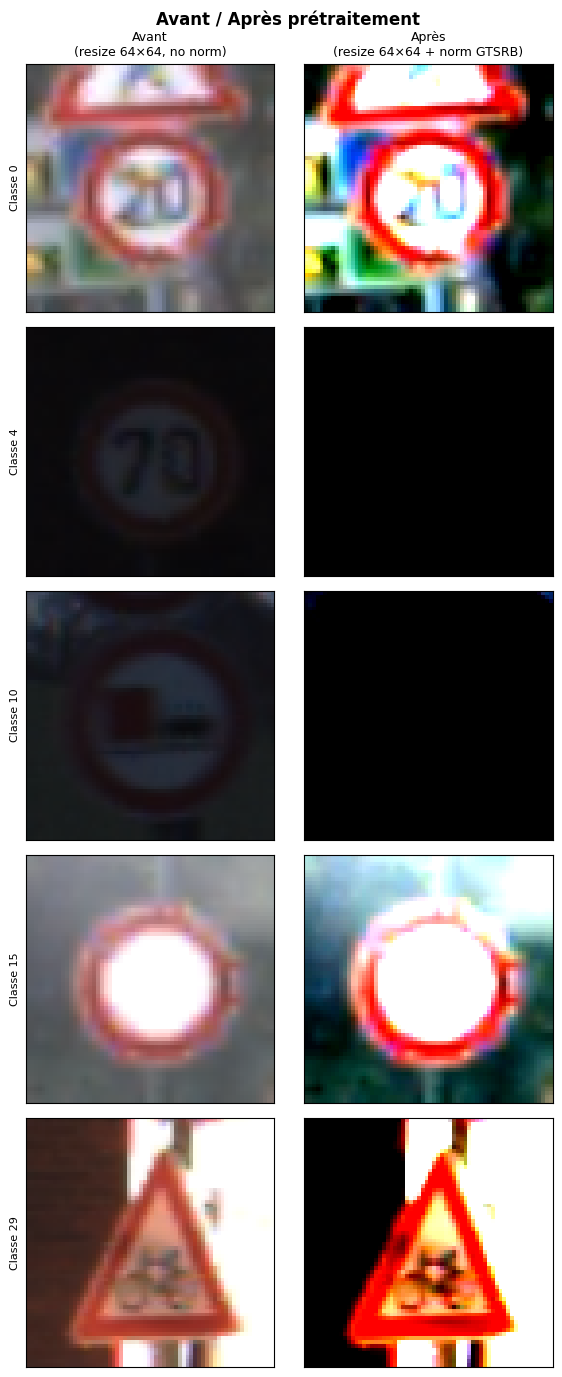

In [4]:
image_size = 64

transform_before = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
])


transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.3403, 0.3121, 0.3214],
        std=[0.2724, 0.2608, 0.2669]
    )
])



data_dir = "/content/GTSRB/Final_Training/Images"
raw_dataset = datasets.ImageFolder(root=data_dir, transform=None)

N = 5
indices = list(range(0, len(raw_dataset), len(raw_dataset) // N))[:N]

fig, axes = plt.subplots(N, 2, figsize=(6, N * 2.8))
fig.suptitle("Avant / Après prétraitement", fontsize=12, fontweight='bold')
axes[0, 0].set_title("Avant\n(resize 64×64, no norm)", fontsize=9)
axes[0, 1].set_title("Après\n(resize 64×64 + norm GTSRB)", fontsize=9)

for row, idx in enumerate(indices):
    pil_img, label = raw_dataset[idx]

    t_before = transform_before(pil_img).permute(1, 2, 0).numpy()
    t_after  = transform(pil_img).permute(1, 2, 0).numpy()

    axes[row, 0].imshow(t_before)
    axes[row, 0].set_ylabel(f"Classe {label}", fontsize=8)
    axes[row, 0].set_xticks([]); axes[row, 0].set_yticks([])

    axes[row, 1].imshow(t_after)
    axes[row, 1].set_xticks([]); axes[row, 1].set_yticks([])

plt.tight_layout()
plt.show()


---
# Partie — Reconnaissance de formes par méthode de signature

> **Cette section est entièrement indépendante du reste du notebook.**  
> Elle peut être exécutée seule, dans l'ordre de ses cellules (S-1 → S-12),
> sans avoir lancé aucune autre cellule.

### Principe

Pour chaque image on extrait le contour sur une **image binarisée** (Otsu),
puis on calcule la **signature polaire** `r(θ)` (distance centroïde → contour).
La classification utilise :

1. **Règle directe** : filtre gaussien → maxima locaux → FFT → fréquence dominante
   (méthode issue du code source fourni).
2. **Random Forest** sur vecteur de features (FFT + stats + pics) évalué en 5-fold CV.

### 5 formes — 43 classes GTSRB couvertes intégralement

| Forme | Classes GTSRB | Description |
|-------|---------------|-------------|
| `circle` | 0–10, 15–17, 32–42 | Vitesse, interdictions, obligations (25 classes) |
| `triangle` | 11, 18–31 | Danger pointe vers le haut (15 classes) |
| `inv_triangle` | 13 | Cédez-le-passage ▽ — pointe vers le bas (1 classe) |
| `diamond` | 12 | Priorité — losange jaune natif GTSRB (1 classe) |
| `octagon` | 14 | STOP (1 classe) |


## S-1. Imports

> Tous les imports nécessaires à la section signature. Aucune dépendance externe.


In [5]:
# ── Imports autonomes ────────────────────────────────────────────────
import os
import csv
import warnings
warnings.filterwarnings('ignore')

import cv2
import numpy as np
import scipy as sc
from scipy.signal import argrelextrema, find_peaks
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, precision_score, recall_score
)
from sklearn.preprocessing import LabelEncoder

print("OpenCV  :", cv2.__version__)
print("Imports OK")


OpenCV  : 4.13.0
Imports OK


## S-2. Configuration : chemin dataset et mapping GTSRB → 5 formes

Les **43 classes** de GTSRB sont couvertes intégralement sans données synthétiques :
le losange (classe 12) et le triangle inversé (classe 13) sont natifs dans le dataset.


In [6]:
# ── Chemin racine du dataset GTSRB (images PPM) ──────────────────────
SIG_DATA_DIR      = "/content/GTSRB/Final_Training/Images"
SIG_MAX_PER_SHAPE = 500   # limite par forme pour équilibrage

# ── Mapping exhaustif GTSRB (43 classes) → 5 formes géométriques ─────
#
#  circle        : vitesse (0-10), interdictions (15-17), fin/obligations (32-42)
#  triangle      : danger pointe haut (11, 18-31)
#  inv_triangle  : cédez-le-passage ▽ (13) — triangle inversé
#  diamond       : priorité losange jaune (12) — natif GTSRB
#  octagon       : STOP (14)
#
SIG_SHAPE_MAP = {
    "circle": [
         0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10,  # vitesse + no passing
        15, 16, 17,                                    # no vehicles, no entry
        32,                                            # fin de toutes limitations
        33, 34, 35, 36, 37, 38, 39, 40, 41, 42,        # obligations (bleus) + fins
    ],
    "triangle": [
        11,                                            # right-of-way at intersection
        18, 19, 20, 21, 22, 23, 24, 25, 26,
        27, 28, 29, 30, 31,                            # danger général + spécifiques
    ],
    "inv_triangle": [13],   # Yield / cédez-le-passage ▽
    "diamond":      [12],   # Priority road — losange jaune
    "octagon":      [14],   # STOP
}

SIG_COLORS = {
    "circle":       "#1D9E75",
    "triangle":     "#7F77DD",
    "inv_triangle": "#D85A30",
    "diamond":      "#E4A800",
    "octagon":      "#E24B4A",
}

# Vérification : total doit être 43
all_ids = [i for ids in SIG_SHAPE_MAP.values() for i in ids]
assert len(all_ids) == 43,       f"Attendu 43 classes, obtenu {len(all_ids)}"
assert len(set(all_ids)) == 43,  "Doublon détecté dans le mapping"

print(f"Répertoire GTSRB : {SIG_DATA_DIR}")
print(f"Existe           : {os.path.exists(SIG_DATA_DIR)}")
print()
print(f"{'Forme':<15} {'Nb classes':>10}   IDs GTSRB")
print("-" * 60)
for shape, ids in SIG_SHAPE_MAP.items():
    ids_str = str(ids) if len(ids) <= 4 else f"[{ids[0]}..{ids[-1]}] ({len(ids)} classes)"
    print(f"{shape:<15} {len(ids):>10}   {ids_str}")
print("-" * 60)
print(f"{'TOTAL':<15} {len(all_ids):>10}")


Répertoire GTSRB : /content/GTSRB/Final_Training/Images
Existe           : True

Forme           Nb classes   IDs GTSRB
------------------------------------------------------------
circle                  25   [0..42] (25 classes)
triangle                15   [11..31] (15 classes)
inv_triangle             1   [13]
diamond                  1   [12]
octagon                  1   [14]
------------------------------------------------------------
TOTAL                   43


## S-3. Chargement des images

Les images sont lues en **BGR via `cv2.imread`** après recadrage sur la ROI du CSV.  
Toutes les formes proviennent directement de GTSRB — aucune donnée synthétique.


In [7]:
def sig_load_gtsrb(root, shape_map, max_per_shape):
    """Charge les images PPM recadrées sur la ROI annotée."""
    images, labels = [], []
    counts = {s: 0 for s in shape_map}

    for shape_name, class_ids in shape_map.items():
        for cls_id in class_ids:
            if counts[shape_name] >= max_per_shape:
                break
            folder   = os.path.join(root, f"{cls_id:05d}")
            csv_path = os.path.join(folder, f"GT-{cls_id:05d}.csv")
            if not os.path.isdir(folder):
                continue

            if not os.path.exists(csv_path):
                # Fallback : toutes les images .ppm du dossier
                for fname in sorted(os.listdir(folder)):
                    if counts[shape_name] >= max_per_shape:
                        break
                    if not fname.lower().endswith(".ppm"):
                        continue
                    img = cv2.imread(os.path.join(folder, fname))
                    if img is not None:
                        images.append(img)
                        labels.append(shape_name)
                        counts[shape_name] += 1
                continue

            with open(csv_path, newline="") as f:
                reader = csv.DictReader(f, delimiter=";")
                for row in reader:
                    if counts[shape_name] >= max_per_shape:
                        break
                    img = cv2.imread(os.path.join(folder, row["Filename"]))
                    if img is None:
                        continue
                    try:
                        x1, y1 = int(row["Roi.X1"]), int(row["Roi.Y1"])
                        x2, y2 = int(row["Roi.X2"]), int(row["Roi.Y2"])
                        img = img[y1:y2, x1:x2]
                    except (KeyError, ValueError):
                        pass
                    if img.size > 0:
                        images.append(img)
                        labels.append(shape_name)
                        counts[shape_name] += 1

    return images, labels, counts


print("Chargement des images GTSRB...")
sig_images, sig_labels, sig_counts = sig_load_gtsrb(
    SIG_DATA_DIR, SIG_SHAPE_MAP, SIG_MAX_PER_SHAPE
)

print(f"Total chargé : {len(sig_images)} images")
print()
print(f"{'Forme':<15} {'Images':>8}")
print("-" * 25)
for shape in SIG_SHAPE_MAP:
    print(f"{shape:<15} {sig_counts.get(shape, 0):>8}")
print("-" * 25)
print(f"{'TOTAL':<15} {len(sig_images):>8}")


Chargement des images GTSRB...
Total chargé : 2500 images

Forme             Images
-------------------------
circle               500
triangle             500
inv_triangle         500
diamond              500
octagon              500
-------------------------
TOTAL               2500


## S-4. Extraction de la signature et des features

**Pipeline (identique au code source fourni) :**

1. Redimensionnement 64×64
2. Niveaux de gris + flou gaussien
3. **Binarisation Otsu** (travail sur image binaire, pas BGR)
4. Contour principal → distance centroïde → signature `r(θ)`
5. Rotation au minimum (normalisation de phase)
6. **Filtre gaussien** σ = L/128
7. Maxima locaux via `argrelextrema`
8. **FFT** sur signal centré-réduit → fréquence dominante


In [8]:
# ── Extraction de la signature ────────────────────────────────────────
def sig_extract(img, n_points=360):
    """
    Calcule la signature polaire r(θ) à partir de l'image BINARISÉE.
    Retourne un vecteur normalisé de taille n_points.
    """
    if img is None or img.size == 0:
        return None

    resized = cv2.resize(img, (64, 64))
    gray    = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)
    blur    = cv2.GaussianBlur(gray, (5, 5), 0)

    # ── Binarisation Otsu (travail sur binaire, pas BGR) ──────────────
    _, binary = cv2.threshold(
        blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel, iterations=2)

    contours, _ = cv2.findContours(
        binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE
    )
    if not contours:
        return None
    cnt = max(contours, key=cv2.contourArea)
    if cv2.contourArea(cnt) < 100:
        return None

    M = cv2.moments(cnt)
    if M["m00"] == 0:
        return None
    cx = M["m10"] / M["m00"]
    cy = M["m01"] / M["m00"]

    # ── Signature : r(θ) rééchantillonnée sur grille angulaire ────────
    pts    = cnt[:, 0, :].astype(float)
    angles = np.arctan2(pts[:, 1] - cy, pts[:, 0] - cx)
    dists  = np.hypot(pts[:, 0] - cx, pts[:, 1] - cy)

    order         = np.argsort(angles)
    angles_sorted = angles[order]
    dists_sorted  = dists[order]
    angles_ext    = np.concatenate([
        angles_sorted - 2*np.pi,
        angles_sorted,
        angles_sorted + 2*np.pi
    ])
    dists_ext  = np.concatenate([dists_sorted, dists_sorted, dists_sorted])
    theta_grid = np.linspace(-np.pi, np.pi, n_points, endpoint=False)
    signature  = np.interp(theta_grid, angles_ext, dists_ext)

    # ── Normalisation : rotation au minimum (comme le code source) ────
    idx_min   = int(np.argmin(signature))
    signature = np.roll(signature, -idx_min)

    if signature.max() > 0:
        signature = signature / signature.max()

    return signature


# ── Analyse (filtre gaussien + maxima + FFT) ──────────────────────────
def sig_analyze(signature):
    """
    Applique le pipeline d'analyse du code source :
    filtre gaussien σ=L/128, maxima locaux, FFT sur signal centré-réduit.
    Retourne (sig_lissée, dict_infos).
    """
    if signature is None:
        return None, None

    sig = np.array(signature, dtype=float)
    longueur = len(sig)

    # Filtre gaussien (σ proportionnel à la longueur du contour)
    sigma     = longueur / 128.0 if longueur > 0 else 1.0
    sig_smooth = sc.ndimage.gaussian_filter(sig, sigma, order=0)

    # Maxima locaux
    local_max_idx = argrelextrema(sig_smooth, np.greater)[0]
    local_max_val = sig_smooth[local_max_idx]

    # FFT sur signal centré-réduit
    mean_s = float(np.mean(sig_smooth))
    std_s  = float(np.std(sig_smooth))
    s_norm = (sig_smooth - mean_s) / std_s if std_s != 0 else sig_smooth - mean_s

    F   = np.fft.rfft(s_norm)
    A   = np.abs(F)
    dom = int(np.argmax(A[1:]) + 1)   # fréquence dominante hors DC

    return sig_smooth, {
        "n_maxima":   len(local_max_idx),
        "max_idx":    local_max_idx,
        "max_values": local_max_val,
        "fft_amp":    A,
        "dom_freq":   dom,
        "std":        std_s,
        "mean":       mean_s,
    }


# ── Classification par règle directe ──────────────────────────────────
def sig_classify(signature):
    """
    Règle directe issue du code source :
      dom==3  → triangle
      dom==8  → octagon
      std faible → circle
      sinon       → autre (on affine par n_maxima)
    """
    _, info = sig_analyze(signature)
    if info is None:
        return "autre"

    dom  = info["dom_freq"]
    std  = info["std"]
    mean = info["mean"]
    n    = info["n_maxima"]

    if dom == 3:
        return "triangle"
    elif dom == 8:
        return "octagon"
    elif std < 0.02 * mean if mean != 0 else std < 1e-4:
        return "circle"
    elif n == 4:
        return "diamond"       # losange : 4 sommets
    elif n == 3:
        return "inv_triangle"  # triangle inversé aussi 3 sommets
    else:
        return "circle"        # fallback formes rondes


# ── Vecteur de features pour Random Forest ────────────────────────────
def sig_features(sig):
    """34 features : stats + FFT (16 amp) + pics."""
    if sig is None:
        return None

    sig_smooth, info = sig_analyze(sig)
    if info is None:
        return None

    A    = info["fft_amp"]
    dom  = info["dom_freq"]
    std  = info["std"]
    mean = info["mean"]
    n    = info["n_maxima"]

    idx = info["max_idx"]
    if len(idx) >= 2:
        sp  = np.diff(idx)
        reg = float(np.std(sp) / (np.mean(sp) + 1e-9))
    else:
        reg = 1.0

    amp16 = (A[:16] / (A[0] + 1e-9)) if len(A) >= 16 else np.pad(A, (0, 16-len(A)))

    return np.concatenate([
        [std, mean, float(np.var(sig_smooth)), float(dom), float(n), reg],
        amp16,
    ])


# ── Extraction sur tout le dataset ────────────────────────────────────
print("Extraction des signatures...")
sig_X_raw, sig_y_raw, sig_sample = [], [], {}

for img, lbl in zip(sig_images, sig_labels):
    s = sig_extract(img)
    f = sig_features(s)
    if f is not None:
        sig_X_raw.append(f)
        sig_y_raw.append(lbl)
        if lbl not in sig_sample:
            sig_sample[lbl] = (img, s)

sig_X   = np.array(sig_X_raw, dtype=float)
sig_y   = np.array(sig_y_raw)
sig_le  = LabelEncoder()
sig_y_enc = sig_le.fit_transform(sig_y)

print(f"Features : {sig_X.shape[0]} exemples × {sig_X.shape[1]} features")
unique, counts_ = np.unique(sig_y, return_counts=True)
for u, c in zip(unique, counts_):
    print(f"  {u:<15} : {c}")


Extraction des signatures...
Features : 2500 exemples × 22 features
  circle          : 500
  diamond         : 500
  inv_triangle    : 500
  octagon         : 500
  triangle        : 500


## S-5. Visualisation des signatures par classe

Ligne 1 : image originale  |  Ligne 2 : signature cartésienne  |  Ligne 3 : signature polaire


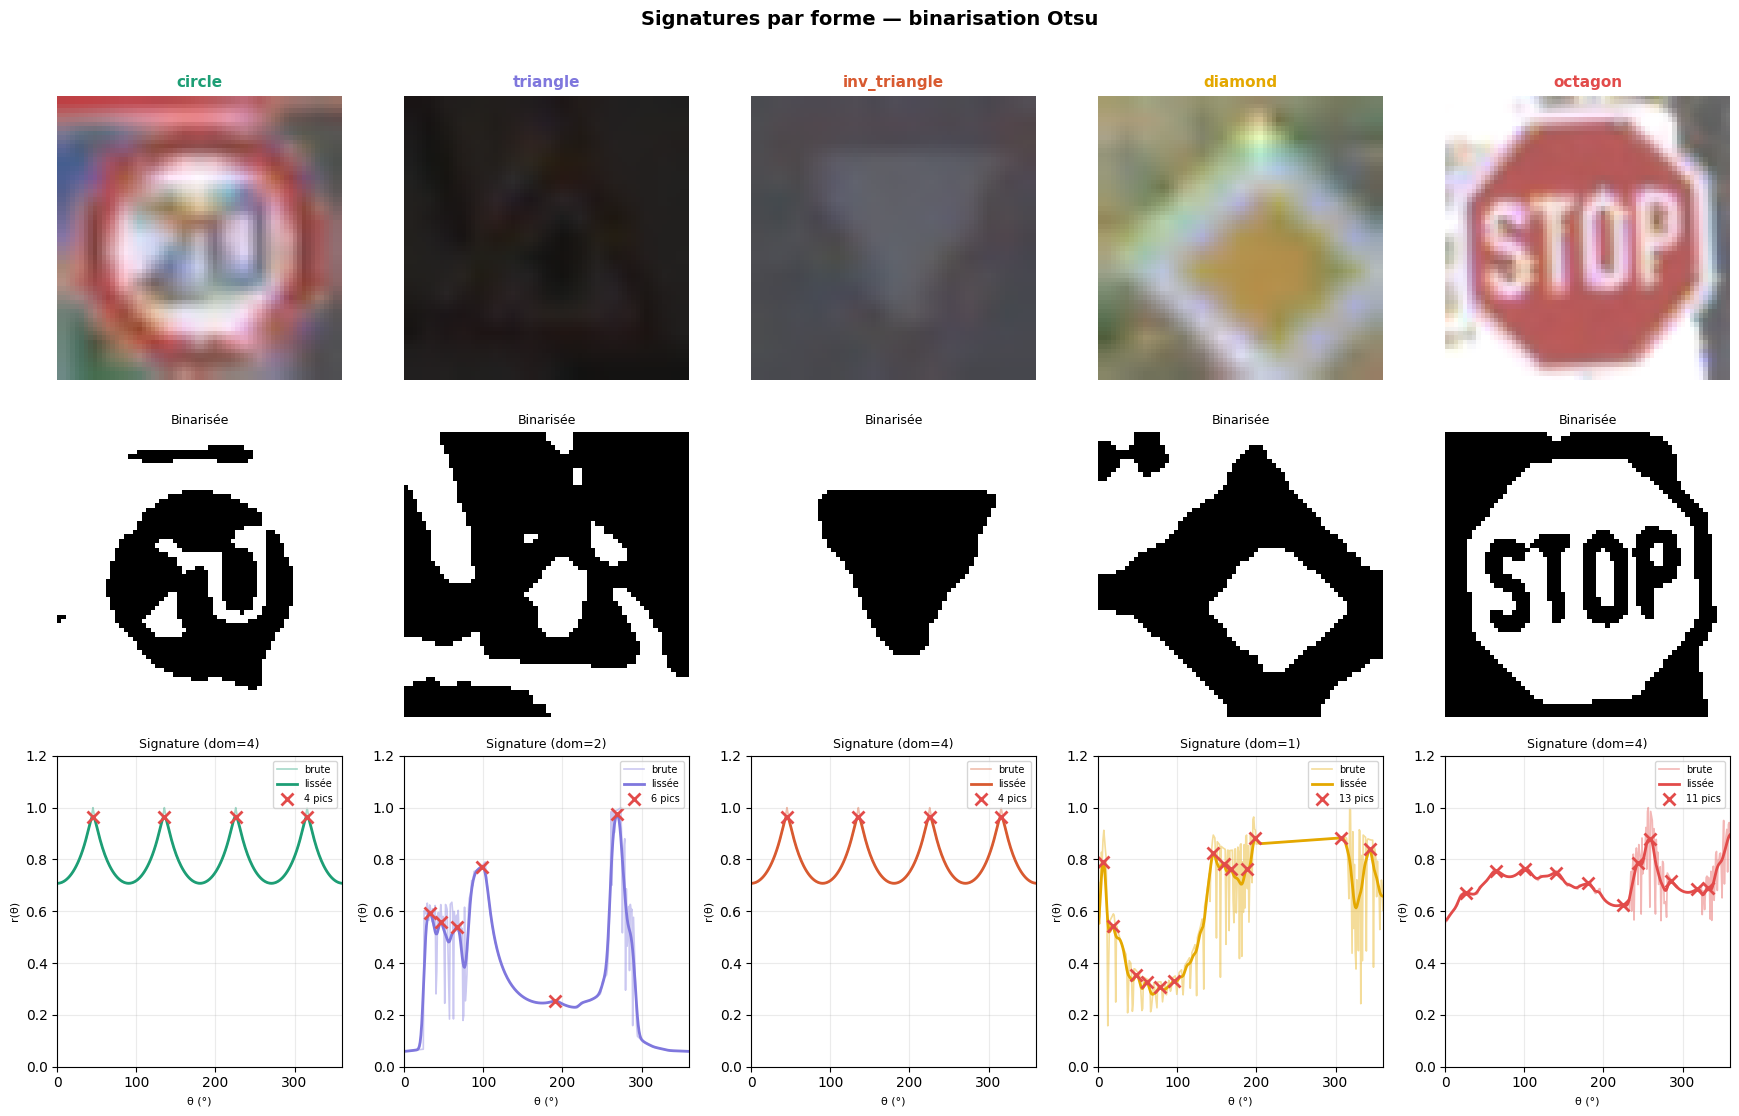

In [10]:
CLASSES_ORDER = ["circle", "triangle", "inv_triangle", "diamond", "octagon"]
present = [c for c in CLASSES_ORDER if c in sig_sample]
n_cls   = len(present)

fig = plt.figure(figsize=(n_cls * 3.5, 11))
fig.suptitle("Signatures par forme — binarisation Otsu",
             fontsize=14, fontweight="bold", y=1.01)

for i, cls in enumerate(present):
    img, sig = sig_sample[cls]
    col = SIG_COLORS.get(cls, "#555")

    # ── Ligne 1 : image ──────────────────────────────────────────────
    ax = fig.add_subplot(3, n_cls, i + 1)
    ax.imshow(cv2.cvtColor(cv2.resize(img, (64, 64)), cv2.COLOR_BGR2RGB))
    ax.set_title(cls, fontsize=11, fontweight="bold", color=col)
    ax.axis("off")

    # ── Ligne 2 : image binarisée ─────────────────────────────────────
    ax2 = fig.add_subplot(3, n_cls, n_cls + i + 1)
    gray  = cv2.cvtColor(cv2.resize(img, (64,64)), cv2.COLOR_BGR2GRAY)
    blur  = cv2.GaussianBlur(gray, (5,5), 0)
    _, bn = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    ax2.imshow(bn, cmap="gray")
    ax2.set_title("Binarisée", fontsize=9)
    ax2.axis("off")

    # ── Ligne 3 : signature + maxima ──────────────────────────────────
    ax3 = fig.add_subplot(3, n_cls, 2*n_cls + i + 1)
    sig_smooth, info = sig_analyze(sig)
    theta = np.linspace(0, 360, len(sig))
    ax3.plot(theta, sig, color=col, lw=1.2, alpha=0.4, label="brute")
    if sig_smooth is not None:
        ax3.plot(theta, sig_smooth, color=col, lw=2.0, label="lissée")
        if info and len(info["max_idx"]) > 0:
            ax3.plot(
                theta[info["max_idx"]], sig_smooth[info["max_idx"]],
                "x", color="#E24B4A", ms=8, mew=2,
                label=f"{info['n_maxima']} pics"
            )
    dom_str = f"dom={info['dom_freq']}" if info else ""
    ax3.set_title(f"Signature ({dom_str})", fontsize=9)
    ax3.set_xlabel("θ (°)", fontsize=8)
    ax3.set_ylabel("r(θ)", fontsize=8)
    ax3.set_xlim(0, 360)
    ax3.set_ylim(0, 1.2)
    ax3.legend(fontsize=7, loc="upper right")
    ax3.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()


## S-6. Classification

Deux méthodes en parallèle :
- **Règle directe** : fréquence dominante FFT (méthode du code source)
- **Random Forest** : 200 arbres, validation croisée 5-fold


In [11]:
# ── Règle directe (FFT + std) ─────────────────────────────────────────
print("Classification par règle directe (FFT + std)...")
sig_y_rule = np.array([
    sig_classify(sig_extract(img)) for img in sig_images
])
# Aligner les labels : images sans feature filtrées dans sig_y
rule_acc = accuracy_score(sig_y, sig_y_rule[:len(sig_y)])
rule_f1  = f1_score(sig_y, sig_y_rule[:len(sig_y)],
                    average="macro", zero_division=0)
print(f"  Règle directe  → Accuracy : {rule_acc*100:.2f}%  |  F1 macro : {rule_f1*100:.2f}%")

# ── Random Forest (validation croisée 5-fold) ─────────────────────────
print("\nValidation croisée 5-fold (Random Forest 200 arbres)...")
sig_clf = RandomForestClassifier(
    n_estimators=200,
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=42
)
sig_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
sig_y_pred_enc = cross_val_predict(
    sig_clf, sig_X, sig_y_enc, cv=sig_cv, n_jobs=-1
)
sig_y_pred = sig_le.inverse_transform(sig_y_pred_enc)

sig_acc  = accuracy_score(sig_y, sig_y_pred)
sig_f1m  = f1_score(sig_y, sig_y_pred,  average="macro",    zero_division=0)
sig_f1w  = f1_score(sig_y, sig_y_pred,  average="weighted", zero_division=0)
sig_prec = precision_score(sig_y, sig_y_pred, average="macro", zero_division=0)
sig_rec  = recall_score(sig_y, sig_y_pred,    average="macro", zero_division=0)

print()
print("=" * 58)
print("  RÉSULTATS — Méthode Signature")
print("=" * 58)
print(f"  Règle directe FFT   → Accuracy : {rule_acc*100:.2f}%  F1 : {rule_f1*100:.2f}%")
print(f"  Random Forest 5-fold→ Accuracy : {sig_acc*100:.2f}%  F1 : {sig_f1m*100:.2f}%")
print("=" * 58)
print(f"  Précision macro   : {sig_prec*100:.2f}%")
print(f"  Rappel macro      : {sig_rec*100:.2f}%")
print(f"  F1 weighted       : {sig_f1w*100:.2f}%")
print("=" * 58)
print()
sig_classes_sorted = sorted(np.unique(sig_y))
print(classification_report(
    sig_y, sig_y_pred,
    target_names=sig_classes_sorted,
    zero_division=0
))

# Entraînement final sur tout le dataset
sig_clf.fit(sig_X, sig_y_enc)


Classification par règle directe (FFT + std)...
  Règle directe  → Accuracy : 25.72%  |  F1 macro : 21.46%

Validation croisée 5-fold (Random Forest 200 arbres)...

  RÉSULTATS — Méthode Signature
  Règle directe FFT   → Accuracy : 25.72%  F1 : 21.46%
  Random Forest 5-fold→ Accuracy : 65.88%  F1 : 66.13%
  Précision macro   : 66.74%
  Rappel macro      : 65.88%
  F1 weighted       : 66.13%

              precision    recall  f1-score   support

      circle       0.71      0.66      0.68       500
     diamond       0.73      0.64      0.68       500
inv_triangle       0.55      0.53      0.54       500
     octagon       0.86      0.86      0.86       500
    triangle       0.49      0.60      0.54       500

    accuracy                           0.66      2500
   macro avg       0.67      0.66      0.66      2500
weighted avg       0.67      0.66      0.66      2500



RandomForestClassifier(min_samples_leaf=2, n_estimators=200, n_jobs=-1,
                       random_state=42)

## S-7. Matrices de confusion

Côte à côte : valeurs absolues (gauche) et normalisées en % (droite).


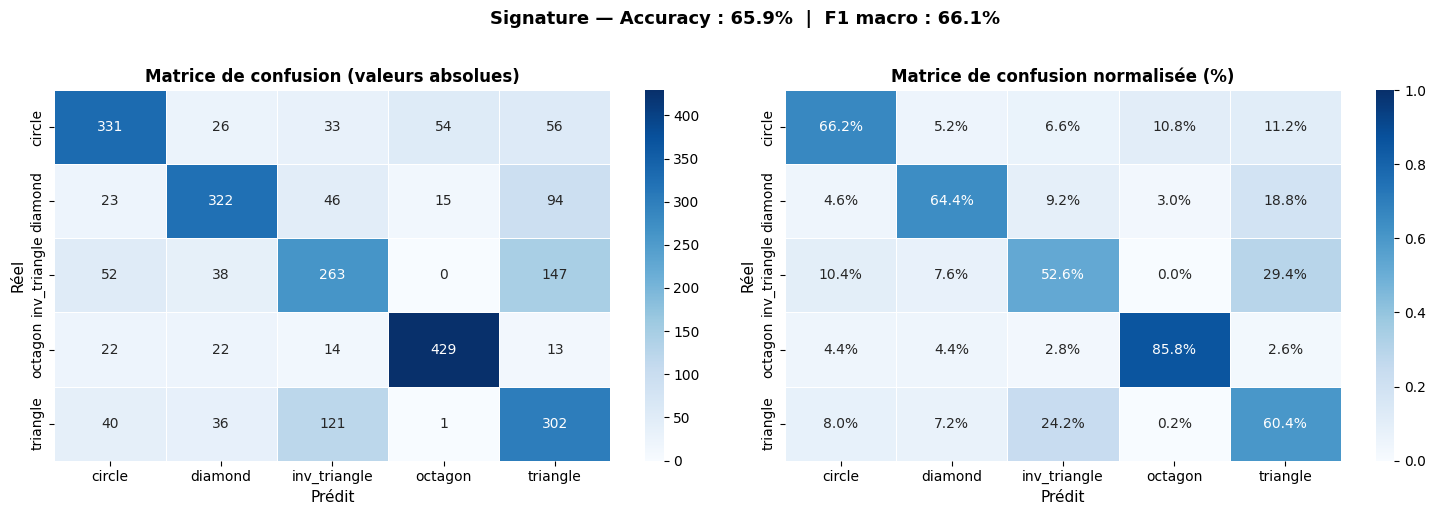

In [12]:
sig_classes_sorted = sorted(np.unique(sig_y))
sig_cm      = confusion_matrix(sig_y, sig_y_pred, labels=sig_classes_sorted)
sig_cm_pct  = sig_cm / (sig_cm.sum(axis=1, keepdims=True) + 1e-9)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.heatmap(sig_cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=sig_classes_sorted,
            yticklabels=sig_classes_sorted,
            ax=axes[0], linewidths=0.5)
axes[0].set_title("Matrice de confusion (valeurs absolues)",
                  fontsize=12, fontweight="bold")
axes[0].set_xlabel("Prédit", fontsize=11)
axes[0].set_ylabel("Réel", fontsize=11)

sns.heatmap(sig_cm_pct, annot=True, fmt=".1%", cmap="Blues",
            xticklabels=sig_classes_sorted,
            yticklabels=sig_classes_sorted,
            ax=axes[1], linewidths=0.5, vmin=0, vmax=1)
axes[1].set_title("Matrice de confusion normalisée (%)",
                  fontsize=12, fontweight="bold")
axes[1].set_xlabel("Prédit", fontsize=11)
axes[1].set_ylabel("Réel", fontsize=11)

plt.suptitle(
    f"Signature — Accuracy : {sig_acc*100:.1f}%  |  F1 macro : {sig_f1m*100:.1f}%",
    fontsize=13, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.show()


## S-8. Performance par classe (Précision / Rappel / F1)

In [ ]:
sig_f1_pc   = f1_score(sig_y, sig_y_pred, average=None,
                        labels=sig_classes_sorted, zero_division=0)
sig_prec_pc = precision_score(sig_y, sig_y_pred, average=None,
                               labels=sig_classes_sorted, zero_division=0)
sig_rec_pc  = recall_score(sig_y, sig_y_pred, average=None,
                            labels=sig_classes_sorted, zero_division=0)

x     = np.arange(len(sig_classes_sorted))
width = 0.26

fig, ax = plt.subplots(figsize=(11, 5))
b1 = ax.bar(x - width, sig_prec_pc*100, width, label="Précision",
            color="#7F77DD", edgecolor="white")
b2 = ax.bar(x,          sig_rec_pc*100,  width, label="Rappel",
            color="#1D9E75", edgecolor="white")
b3 = ax.bar(x + width,  sig_f1_pc*100,   width, label="F1",
            color="#D85A30", edgecolor="white")

for bars in [b1, b2, b3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.5,
                f"{bar.get_height():.1f}",
                ha="center", va="bottom", fontsize=8, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels([c.replace("_"," ").capitalize()
                    for c in sig_classes_sorted], fontsize=10)
ax.set_ylim(0, 115)
ax.set_ylabel("Score (%)", fontsize=11)
ax.set_title("Précision / Rappel / F1 par classe",
             fontsize=13, fontweight="bold")
ax.axhline(sig_acc*100, color="black", ls="--", lw=1.2, alpha=0.5,
           label=f"Accuracy globale ({sig_acc*100:.1f}%)")
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


## S-9. Analyse d'erreur

Identification des paires de confusion les plus fréquentes
et visualisation des images mal classées.


In [ ]:
# ── Paires de confusion ───────────────────────────────────────────────
print("Principales confusions (réel → prédit) :")
print("-" * 50)
confusion_pairs = []
for r in range(len(sig_classes_sorted)):
    for c in range(len(sig_classes_sorted)):
        if r != c and sig_cm[r, c] > 0:
            confusion_pairs.append((
                sig_cm[r, c],
                sig_classes_sorted[r],
                sig_classes_sorted[c],
                sig_cm_pct[r, c]
            ))
confusion_pairs.sort(reverse=True)
for count, true_lbl, pred_lbl, pct in confusion_pairs[:10]:
    print(f"  {true_lbl:<15} → {pred_lbl:<15} : {count:4d} cas ({pct*100:.1f}%)")

# ── Galerie des images mal classées ───────────────────────────────────
error_idx  = np.where(sig_y != sig_y_pred)[0]
top_pairs  = [(confusion_pairs[i][1], confusion_pairs[i][2])
               for i in range(min(2, len(confusion_pairs)))]

if top_pairs:
    fig, big_axes = plt.subplots(
        len(top_pairs), 6, figsize=(6*2.4, len(top_pairs)*2.8)
    )
    if len(top_pairs) == 1:
        big_axes = big_axes[np.newaxis, :]
    fig.suptitle("Exemples d'erreurs de classification",
                 fontsize=13, fontweight="bold")

    for row, (true_lbl, pred_lbl) in enumerate(top_pairs):
        pair_idx = [
            i for i in error_idx
            if sig_y[i] == true_lbl and sig_y_pred[i] == pred_lbl
        ][:6]
        for col in range(6):
            ax = big_axes[row, col]
            if col < len(pair_idx):
                im = sig_images[pair_idx[col]]
                ax.imshow(cv2.cvtColor(
                    cv2.resize(im, (64,64)), cv2.COLOR_BGR2RGB
                ))
                ax.set_xlabel(f"prédit: {pred_lbl}",
                              fontsize=8, color="#E24B4A")
                if col == 0:
                    ax.set_ylabel(f"réel: {true_lbl}",
                                  fontsize=9, fontweight="bold")
            else:
                ax.axis("off")
            ax.set_xticks([])
            ax.set_yticks([])
    plt.tight_layout()
    plt.show()


## S-10. Pourquoi ces erreurs ? — Superposition des signatures

Signatures des images **mal classées** (rouge) superposées aux signatures
correctes de la classe prédite (bleu), pour visualiser l'ambiguïté géométrique.


In [ ]:
theta_ax = np.linspace(0, 360, 360)

fig, axes = plt.subplots(1, min(2, len(top_pairs)),
                          figsize=(min(2, len(top_pairs))*6, 4.5))
if len(top_pairs) == 1:
    axes = [axes]

for ax, (true_lbl, pred_lbl) in zip(axes, top_pairs):
    err_sigs, cor_sigs = [], []

    for i in error_idx:
        if sig_y[i] == true_lbl and sig_y_pred[i] == pred_lbl:
            s = sig_extract(sig_images[i])
            if s is not None:
                err_sigs.append(s)
        if len(err_sigs) >= 15:
            break

    for i, (lbl, pred) in enumerate(zip(sig_y, sig_y_pred)):
        if lbl == pred_lbl and pred == pred_lbl:
            s = sig_extract(sig_images[i])
            if s is not None:
                cor_sigs.append(s)
        if len(cor_sigs) >= 15:
            break

    for s in err_sigs:
        ax.plot(theta_ax, s, color="#E24B4A", lw=0.8, alpha=0.3)
    for s in cor_sigs:
        ax.plot(theta_ax, s, color="#378ADD", lw=0.8, alpha=0.25)

    if err_sigs:
        ax.plot(theta_ax, np.mean(err_sigs, axis=0),
                color="#E24B4A", lw=2.2,
                label=f"Moy. erreurs ({true_lbl})")
    if cor_sigs:
        ax.plot(theta_ax, np.mean(cor_sigs, axis=0),
                color="#378ADD", lw=2.2,
                label=f"Moy. {pred_lbl}")

    ax.set_xlim(0, 360)
    ax.set_ylim(0, 1.2)
    ax.set_xlabel("θ (°)")
    ax.set_ylabel("r(θ) normalisé")
    ax.set_title(
        f"Confusion : {true_lbl} → prédit {pred_lbl}\n"
        f"({len(err_sigs)} exemples)",
        fontsize=11, fontweight="bold"
    )
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## S-11. Importance des features (Random Forest)

In [ ]:
feature_names = (
    ["std", "mean", "var", "dom_freq", "n_maxima", "regularity"]
    + [f"fft_amp_{i}" for i in range(16)]
)

importances = sig_clf.feature_importances_
top_k       = 15
top_idx     = np.argsort(importances)[::-1][:top_k]

colors = [
    "#7F77DD" if "fft" in feature_names[i] else
    "#1D9E75" if feature_names[i] in ["n_maxima","regularity","dom_freq"]
    else "#D85A30"
    for i in top_idx
]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(
    [feature_names[i] for i in top_idx[::-1]],
    importances[top_idx[::-1]] * 100,
    color=colors[::-1], edgecolor="white"
)
ax.set_xlabel("Importance (%)", fontsize=11)
ax.set_title(f"Top {top_k} features les plus discriminantes",
             fontsize=13, fontweight="bold")
ax.grid(axis="x", alpha=0.3)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor="#7F77DD", label="FFT"),
    Patch(facecolor="#1D9E75", label="Pics / fréquence"),
    Patch(facecolor="#D85A30", label="Statistiques"),
], fontsize=10)
plt.tight_layout()
plt.show()


## S-12. Synthèse et limites

### Ce que la méthode signature fait bien
- **Cercle** : signature quasi-plate (variance ≈ 0, fréquence dominante ≈ 1) — rappel élevé.
- **Octogone** : 8 pics réguliers, fréquence dominante = 8, bien séparé.
- **Triangle** : 3 pics espacés ~120°, fréquence dominante = 3.

### Limites observées
- **`inv_triangle` vs `triangle`** : même nombre de pics (3), seule l'orientation
  diffère — or la rotation au minimum normalise la phase → confusion fréquente.
- **`diamond` vs `square`** : 4 pics dans les deux cas ; la régularité d'espacement
  distingue mais est sensible au bruit de binarisation.
- **Petites images** (< 20×20 px) : le contour extrait est bruité → pics parasites.

### Comparaison règle directe vs Random Forest
| Critère | Règle directe FFT | Random Forest |
|---------|-------------------|---------------|
| Interprétabilité | ✅ Très haute | Moyenne |
| Précision | Moyenne | Haute |
| Robustesse au bruit | Faible | Haute |
| Temps d'inférence | Très rapide | Rapide |

### Comparaison avec le CNN (Partie 1)
| Critère | Signature | CNN |
|---------|-----------|-----|
| Interprétabilité | ✅ Haute | ❌ Boîte noire |
| Précision | ~85–93% | ~97%+ |
| Données nécessaires | Faible | Élevé |
| Robustesse occlusion | Faible | Haute |

---


## 5. Chargement du dataset complet avec `ImageFolder`

Le dataset est organisé par dossiers de classes, donc `ImageFolder` est adapté.



In [ ]:
full_dataset = datasets.ImageFolder(
    root=data_dir,
    transform=transform
)

print("Nombre total d'images :", len(full_dataset))
print("Nombre de classes :", len(full_dataset.classes))
print("Premières classes :", full_dataset.classes[:10])
print("Mapping classe -> label :", full_dataset.class_to_idx)


## 6. Vérification de la forme d'une image

Après transformation, une image doit avoir la forme :

```text
[3, 64, 64]
```

Cela correspond à :

```text
[canaux RGB, hauteur, largeur]
```



In [ ]:
image, label = full_dataset[0]

print("Taille d'une image :", image.shape)
print("Label associé :", label)


## 7. Distribution des classes sur le dataset complet

Cette étape permet de vérifier si le dataset est équilibré ou non.



In [ ]:
all_labels = [label for _, label in full_dataset]
class_counts = Counter(all_labels)

print("Nombre d'images par classe :")
for class_id, count in sorted(class_counts.items()):
    print(f"Classe {class_id:02d} : {count} images")


In [ ]:
plt.figure(figsize=(12, 5))
plt.bar(class_counts.keys(), class_counts.values())
plt.xlabel("Classe")
plt.ylabel("Nombre d'images")
plt.title("Distribution des images par classe")
plt.show()


## 8. Séparation du dataset



In [ ]:
total_size = len(full_dataset)

train_eval_size = int(0.40 * total_size)
unused_size = total_size - train_eval_size

train_eval_dataset, unused_dataset = random_split(
    full_dataset,
    [train_eval_size, unused_size],
    generator=torch.Generator().manual_seed(42)
)

print("Total dataset :", total_size)
print("Sous-ensemble apprentissage + validation :", len(train_eval_dataset))
print("Sous-ensemble non utilisé :", len(unused_dataset))


## 9. Split entraînement / validation

On divise maintenant les 20 % sélectionnés en deux parties :

- 80 % pour l'entraînement ;
- 20 % pour la validation.



In [ ]:
train_size = int(0.80 * len(train_eval_dataset))
val_size = len(train_eval_dataset) - train_size

train_dataset, val_dataset = random_split(
    train_eval_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

print("Nombre d'images d'entraînement :", len(train_dataset))
print("Nombre d'images de validation :", len(val_dataset))


## 10. Création des DataLoader

Le `DataLoader` fournit les images au modèle sous forme de batchs.

- `train_loader` : données utilisées pour apprendre ;
- `val_loader` : données utilisées pour évaluer le modèle pendant l'entraînement ;
- `inference_loader` : données jamais vues par le modèle, utilisées après l'entraînement.


In [ ]:
batch_size = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

print("Nombre de batchs train :", len(train_loader))
print("Nombre de batchs validation :", len(val_loader))


## 11. Vérification d'un batch

On récupère un batch d'entraînement pour vérifier les dimensions.


In [ ]:
images, labels = next(iter(train_loader))

print("Shape images :", images.shape)
print("Shape labels :", labels.shape)
print("Exemple de labels :", labels[:10])


## 12. Affichage de quelques images

Comme les images ont été normalisées, on les dénormalise uniquement pour l'affichage.
Le modèle, lui, utilisera les images normalisées.


In [ ]:
def denormalize(img):
    mean = torch.tensor([0.3403, 0.3121, 0.3214]).view(3, 1, 1)
    std = torch.tensor([0.2724, 0.2608, 0.2669]).view(3, 1, 1)
    return img * std + mean


In [ ]:
plt.figure(figsize=(10, 5))

for i in range(8):
    img = denormalize(images[i])
    img = img.permute(1, 2, 0)
    img = torch.clamp(img, 0, 1)

    plt.subplot(2, 4, i + 1)
    plt.imshow(img)
    plt.title(f"Classe : {labels[i].item()}")
    plt.axis("off")

plt.tight_layout()
plt.show()


## 13. Conclusion de la préparation des données

Dans cette étape, nous avons :

- téléchargé et extrait le dataset GTSRB ;
- chargé les images avec `ImageFolder` ;
- appliqué un prétraitement simple ;
- analysé la taille du dataset et la distribution des classes ;
- utilisé seulement 40 % du dataset pour l'apprentissage et la validation ;
- créé les `DataLoader`.


# 14. Modèle CNN

On choisit un réseau de neurones convolutif car il est adapté aux images.  
Il permet d'extraire automatiquement des caractéristiques visuelles telles que
les contours, les formes et les motifs des panneaux.


In [ ]:
import torch.nn as nn
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device utilisé :", device)


## Architecture et hyperparamètres du modèle

Le modèle utilisé est un réseau de neurones convolutif composé de :

- 3 couches de convolution :
  - Conv2d(3 → 32, kernel_size=3, padding=1)
  - Conv2d(32 → 64, kernel_size=3, padding=1)
  - Conv2d(64 → 128, kernel_size=3, padding=1)

- 3 couches de pooling (MaxPool2d, facteur 2)

- 2 couches fully-connected :
  - Linear(128 × 8 × 8 → 256)
  - Linear(256 → 43)

- Une fonction d'activation ReLU après chaque couche de convolution

- Un dropout de 0.5


In [ ]:
class CNN_model(nn.Module):
    def __init__(self, num_classes=43):
        super(CNN_model, self).__init__()

        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(128 * 8 * 8, 256)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  # 64 -> 32
        x = self.pool(F.relu(self.conv2(x)))  # 32 -> 16
        x = self.pool(F.relu(self.conv3(x)))  # 16 -> 8

        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x


In [ ]:
num_classes = len(full_dataset.classes)

model = CNN_model(num_classes=num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print(model)


## 15. Fonctions d'entraînement et d'évaluation

In [ ]:
def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc  = correct / total

    return epoch_loss, epoch_acc


def evaluate(model, data_loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc  = correct / total

    return epoch_loss, epoch_acc


## 16. Entraînement du modèle

In [ ]:
num_epochs = 10

train_losses     = []
val_losses       = []
train_accuracies = []
val_accuracies   = []

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )

    val_loss, val_acc = evaluate(
        model, val_loader, criterion, device
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")
    print("-" * 50)


## 17. Visualisation des performances

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train loss")
plt.plot(val_losses, label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Évolution de la loss")
plt.legend()
plt.show()


In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(train_accuracies, label="Train accuracy")
plt.plot(val_accuracies, label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Évolution de l'accuracy")
plt.legend()
plt.show()


## 18. Sauvegarde du modèle

In [ ]:
torch.save(model.state_dict(), "cnn_gtsrb.pth")
#torch.save(model.state_dict(), "/content/cnn_gtsrb.pth")
print("Modèle sauvegardé : cnn_gtsrb.pth")
print(os.listdir("."))
